Dataset Loaded Successfully!

First 5 Rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Shape:
(150, 6)

Column Names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-nul

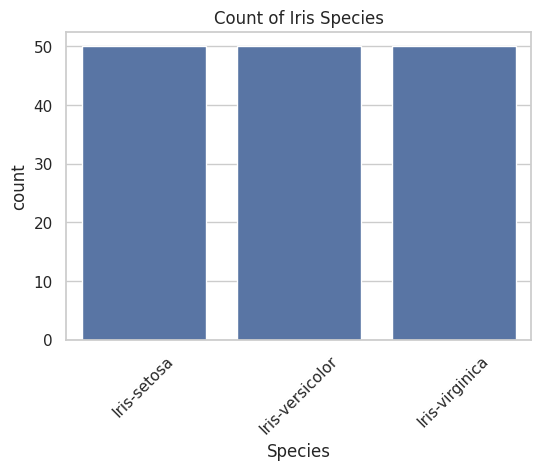

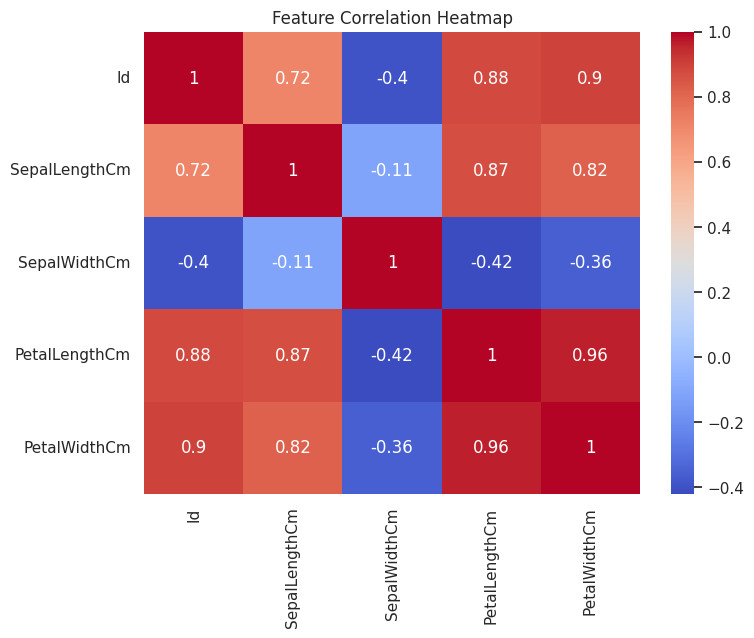

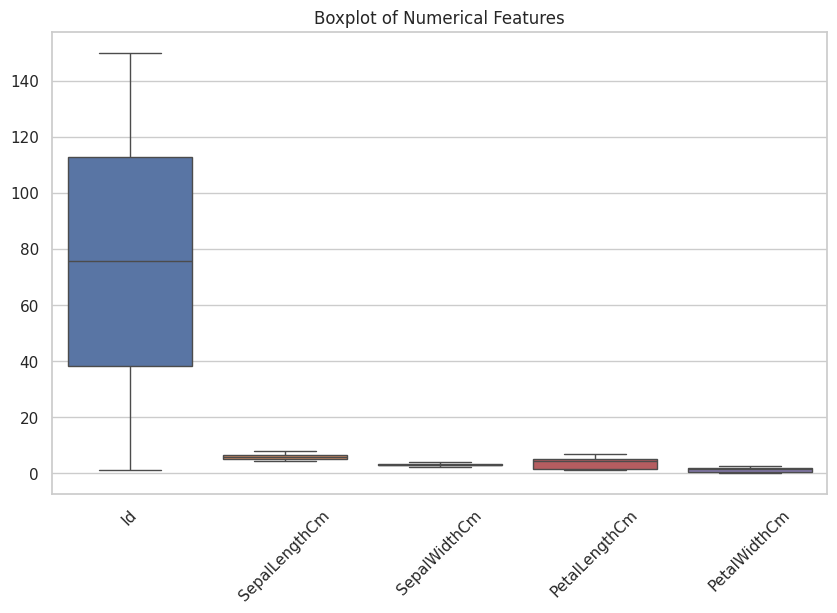

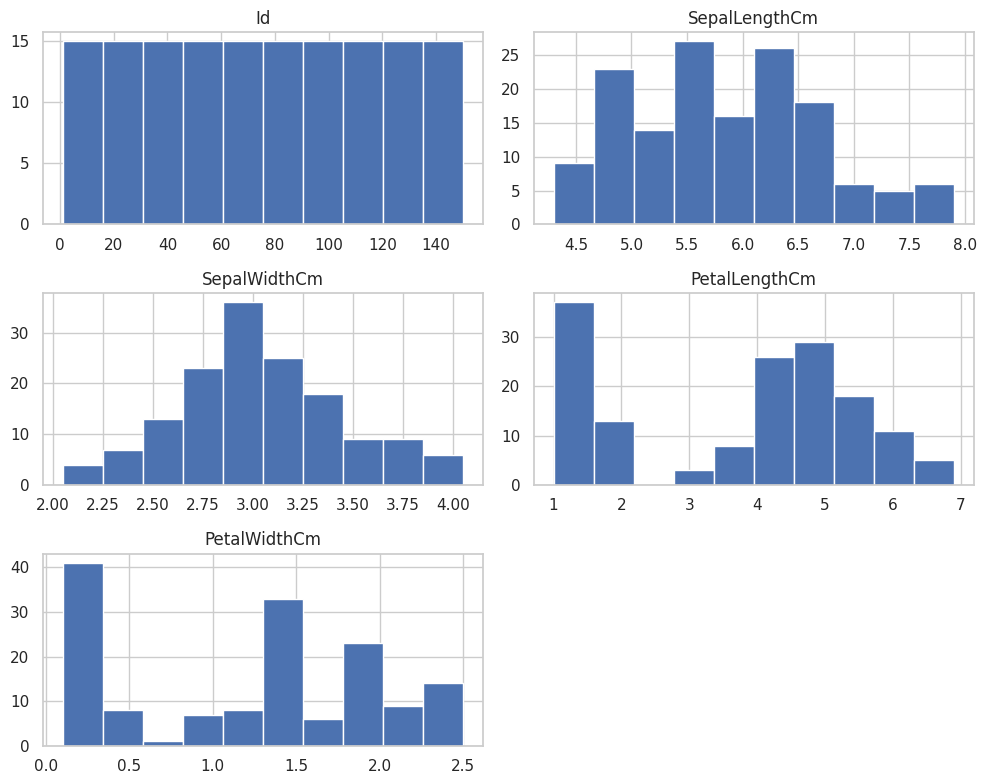


Cleaned dataset saved as 'cleaned_iris_dataset.csv'

Project Completed Successfully!


In [7]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 2. Load Dataset
df = pd.read_excel("/content/Iris.xlsx")
# Clean column names
df.columns = df.columns.str.strip()
print("Dataset Loaded Successfully!\n")
# 3. Basic Exploration
print("First 5 Rows:")
print(df.head())
print("\nDataset Shape:")
print(df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
# 4. Detect Species Column
categorical_cols = df.select_dtypes(include='object').columns
if len(categorical_cols) > 0:
    target_col = categorical_cols[0]
    print(f"\nDetected species column: {target_col}")
else:
    print("No categorical species column found.")
    target_col = None
# 5. Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())
# 6. Fill missing numeric values with median
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
print("\nMissing values after handling:")
print(df.isnull().sum())
# 7. Remove Duplicate Rows
print("\nDuplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)
# 8. Handle Outliers
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])
print("\nOutliers handled successfully.")
# 9. Data Visualization
sns.set(style="whitegrid")
if target_col:
    plt.figure(figsize=(6,4))
    sns.countplot(x=target_col, data=df)
    plt.title("Count of Iris Species")
    plt.xticks(rotation=45)
    plt.show()
# ---- Correlation Heatmap ----
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()
# ---- Boxplots ----
plt.figure(figsize=(10,6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()
# ---- Histograms ----
df[numeric_cols].hist(figsize=(10,8))
plt.tight_layout()
plt.show()
# 10. Save Cleaned Dataset
df.to_csv("cleaned_iris_dataset.csv", index=False)
print("\nCleaned dataset saved as 'cleaned_iris_dataset.csv'")
print("\nProject Completed Successfully!")